# PPO from scratch — **V6-continuous: minibatched PPO on MuJoCo `InvertedPendulum-v5`**

A minimal fork of **V6_1** onto a **continuous** action space. The whole GPU-shaped pipeline is
unchanged — 512 envs stepped as one batch, a persistent `state`, critic values recorded during
collection, GAE-λ over the `(T, N)` grid with the autoreset bootstrap, a shuffled `DataLoader`,
the clipped minibatch update, and the KL brake. Only the three things that *have* to change for a
continuous env change:

1. **Gaussian policy.** The net outputs an action **mean**; the log-std is a learned
   state-independent `nn.Parameter` (CleanRL / SpinningUp style). `forward` returns
   `Independent(Normal(mean, std), 1)` — the `Independent` wrapper sums `log_prob` and `entropy`
   over the action dimensions, so **the PPO helpers and the update loop are byte-identical to V6_1**.
2. **Continuous actions everywhere they touch the env.** `sample()` gives a float vector per lane;
   "greedy" is the distribution **mean**; eval/GIF clip to the action box `[-3, 3]`.
3. **`ACT_DIM` replaces `N_ACTS`.** Actions are `(N, act_dim)` grids; the critic, GAE, buffer, and
   loader are otherwise untouched.

It also carries the same **PPO implementation-detail hardening** as the updated V6_1, ported here
(A1–A4 of `ppo_implementation_notes.md`): **orthogonal init** (√2 hidden / 0.01 **mean** head / 1.0
value head), per-net **gradient clipping** (`MAX_GRAD_NORM`, covering `log_std`), **linear LR
annealing**, and the **k3 KL estimator** with a **clipfrac** diagnostic.

`InvertedPendulum-v5` is the true MuJoCo env (needs `pip install "gymnasium[mujoco]"`): reward is
**+1 per step**, the episode **terminates** the moment the pole falls, and truncates at the
1000-step cap. So "return" is just how long the pole stays up — **solved ≈ 1000**. Note this flips
the autoreset semantics vs. Acrobot: here a *terminated* lane is a **fall** (still bootstrap 0),
and truncations are rare (only a policy good enough to survive 1000 steps ever hits the cap).

## Imports & configuration *(given)*

In [13]:
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.distributions.normal import Normal
from torch.distributions.independent import Independent
from torch.utils.data import DataLoader, TensorDataset
import gymnasium as gym
from gymnasium.vector import AutoresetMode

ENV_NAME       = "InvertedPendulum-v5"   # MuJoCo, continuous force Box(-3, 3)
SEED           = 0
HIDDEN         = [64, 64]

# ---- collection shape (from V6_0) -------------------------------------------
N_ENVS         = 512      # inference batch: envs stepped as one forward
ROLLOUT_STEPS  = 80       # vector steps per collection -> 512 x 80 = 40_960 samples
MINIBATCH_SIZE = 4096     # update batch: the DataLoader minibatch (=> 10 per walk)
EPOCHS         = 15       # collections; each is a fresh 40_960-sample dataset

# ---- GAE / PPO (from V3-V5) -------------------------------------------------
GAMMA          = 0.99
LAM            = 0.95     # GAE-lambda
CLIP_RATIO     = 0.2      # PPO clip epsilon
TARGET_KL      = 0.01     # stop the update once a walk's approx KL exceeds ~1.5x this

# ---- NEW in V6_1: the minibatched update ------------------------------------
UPDATE_EPOCHS  = 4        # ceiling on walks over the rollout per collection; KL brakes early
PI_LR          = 1e-3     # continuous control likes a gentler policy LR than discrete Acrobot's 2e-3
VALUE_LR       = 3e-3
ENT_COEF       = 0.0      # MuJoCo convention: no entropy bonus (the learned Gaussian std explores)
MAX_GRAD_NORM  = 0.5      # global-norm gradient clip on each net (CleanRL default)

print("gymnasium", gym.__version__, "| torch", torch.__version__)

gymnasium 1.3.0 | torch 2.13.0+cpu


## Policy, critic & envs *(Gaussian `MyPolicy` for continuous actions; `MyCritic` from V5 — now with orthogonal init)*

Both nets use **orthogonal weight init** via the `layer_init` helper: `√2` on the Tanh hidden
layers, **`0.01` on the policy mean head** (so the initial action mean sits near zero, centered in
the `[-3, 3]` box), and `1.0` on the value head. The learned `log_std` starts at 0 (initial σ = 1).
This is A1 from `ppo_implementation_notes.md`, ported from V6_1 — the discrete-policy 0.01 head
becomes the continuous **mean** head.

In [14]:
def layer_init(layer, std=np.sqrt(2), bias_const=0.0):
    nn.init.orthogonal_(layer.weight, std)
    nn.init.constant_(layer.bias, bias_const)
    return layer


class MyPolicy(nn.Module):
    """Gaussian policy: the net outputs the action mean; the log-std is a learned,
    state-independent parameter (CleanRL / SpinningUp style). `Independent(Normal, 1)`
    sums log_prob/entropy over the action dims, so the PPO update stays identical to V6_1.
    Weights use orthogonal init: sqrt(2) on the hidden layers, 0.01 on the mean head so the
    initial action mean sits near zero (centered in the action box)."""
    def __init__(self, input_size: int, output_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(layer_init(nn.Linear(in_sz, out_sz)))
            layers.append(nn.Tanh())
        layers.append(layer_init(nn.Linear(HIDDEN[-1], output_size), std=0.01))
        self.mean_layers = nn.Sequential(*layers)
        self.log_std = nn.Parameter(torch.zeros(output_size))

    def forward(self, x: torch.Tensor) -> Independent:
        mean = self.mean_layers(x)
        std = torch.exp(self.log_std).expand_as(mean)
        return Independent(Normal(mean, std), 1)

    def greedy(self, x: torch.Tensor) -> torch.Tensor:
        return self.mean_layers(x)                       # deterministic action = the mean

    def sample_with_logprob(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        distribution = self.forward(x)
        action = distribution.sample()
        return action, distribution.log_prob(action)


class MyCritic(nn.Module):
    def __init__(self, input_size: int) -> None:
        super().__init__()
        sizes = [input_size] + HIDDEN
        layers = []
        for in_sz, out_sz in zip(sizes, sizes[1:]):
            layers.append(layer_init(nn.Linear(in_sz, out_sz)))
            layers.append(nn.Tanh())
        layers.append(layer_init(nn.Linear(HIDDEN[-1], 1), std=1.0))
        self.linear_layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layers(x).squeeze(-1)


def make_vec_env(n_envs: int = N_ENVS, env_name: str = ENV_NAME) -> gym.vector.VectorEnv:
    return gym.make_vec(env_name, num_envs=n_envs, vectorization_mode="sync",
                        vector_kwargs={"autoreset_mode": AutoresetMode.SAME_STEP})


def make_env(env_name: str = ENV_NAME, render_mode: str | None = None) -> gym.Env:
    return gym.make(env_name, render_mode=render_mode)


_ve = make_vec_env(2)
_o, _ = _ve.reset(seed=0)
OBS_DIM  = _ve.single_observation_space.shape[0]
ACT_DIM  = _ve.single_action_space.shape[0]
ACT_LOW  = float(_ve.single_action_space.low[0])
ACT_HIGH = float(_ve.single_action_space.high[0])
print(f"{ENV_NAME}: obs_dim={OBS_DIM}, act_dim={ACT_DIM}, "
      f"action in [{ACT_LOW}, {ACT_HIGH}] | autoreset {_ve.metadata['autoreset_mode']}")
_ve.close()

InvertedPendulum-v5: obs_dim=4, act_dim=1, action in [-3.0, 3.0] | autoreset AutoresetMode.SAME_STEP


## PPO / critic / KL / normalization helpers *(your V4–V5 code — KL upgraded to the k3 estimator)*

`compute_approx_kl` now uses Schulman's **k3** estimator `((r − 1) − log r).mean()` where
`r = exp(logp − logp_old) = π_new/π_old` (summed over action dims by `Independent`), instead of the
noisier **k1**. k3 is unbiased *and* always ≥ 0 with much lower variance, so the `1.5 · TARGET_KL`
early-stop threshold means the same thing every run. This is A3, ported from V6_1.

In [15]:
def normalize_advantages(adv: torch.Tensor) -> torch.Tensor:
    adv = adv - adv.mean()
    if adv.std() > 0:
        adv = adv / adv.std()
    return adv


def compute_ppo_loss(current_logp: torch.Tensor, adv: torch.Tensor,
                     logp_old: torch.Tensor, clip_ratio: float) -> torch.Tensor:
    ratio = torch.exp(current_logp - logp_old)
    clipped_ratio = torch.clip(ratio, 1 - clip_ratio, 1 + clip_ratio)
    return -torch.min(ratio * adv, clipped_ratio * adv).mean()


def compute_value_loss(critic: MyCritic, obs: torch.Tensor, returns: torch.Tensor) -> torch.Tensor:
    return F.mse_loss(critic(obs), returns)


def compute_approx_kl(current_logp: torch.Tensor, logp_old: torch.Tensor) -> float:
    logratio = current_logp - logp_old
    #return -logratio.mean().item()  # k1 estimator
    ratio = logratio.exp()
    return ((ratio - 1) - logratio).mean().item()      # k3: unbiased, low-variance, >= 0

## Eval & GIF *(given)*

In [16]:
def greedy_action(policy_net: MyPolicy, obs: np.ndarray) -> np.ndarray:
    with torch.no_grad():
        action = policy_net.greedy(torch.tensor(obs, dtype=torch.float32))
    return np.clip(action.numpy(), ACT_LOW, ACT_HIGH)      # keep the mean inside the action box


def evaluate(policy_net: MyPolicy, n_episodes: int = 10, seed: int = 1000) -> tuple[float, float]:
    env = make_env()
    rets = []
    for i in range(n_episodes):
        obs, _ = env.reset(seed=seed + i)
        done, ep_ret = False, 0.0
        while not done:
            obs, r, terminated, truncated, _ = env.step(greedy_action(policy_net, obs))
            done = terminated or truncated
            ep_ret += r
        rets.append(ep_ret)
    env.close()
    return float(np.mean(rets)), float(np.std(rets))


def record_gif(policy_net: MyPolicy, out_path: str, episodes: int = 3,
               fps: int = 30, max_frames: int = 600) -> None:
    try:
        import imageio
        env = make_env(render_mode="rgb_array")
        frames = []
        for _ in range(episodes):
            obs, done = env.reset()[0], False
            while not done and len(frames) < max_frames:      # a solved pole runs 1000 steps -> cap the gif
                frames.append(env.render())
                obs, _, terminated, truncated, _ = env.step(greedy_action(policy_net, obs))
                done = terminated or truncated
            if len(frames) >= max_frames:
                break
        env.close()
        imageio.mimsave(out_path, frames, fps=fps)
        print(f"saved {len(frames)} frames -> {out_path}")
        from IPython.display import Image, display
        display(Image(filename=out_path))
    except Exception as ex:
        print("record_gif skipped (likely headless):", repr(ex))

## RolloutBuffer *(given — your V6_0 buffer, now also carrying critic values)*

Same list-of-per-step-tensors design as V6_0, extended with two new columns: `value` = `V(s_t)`
and `next_value` = the bootstrap value for the GAE delta (you fill both in `collect_rollout`).
`get_grids()` stacks every column along time into **(T, N, …)** grids — the un-flattened shape
GAE needs. Flattening to `(T·N, …)` happens *after* GAE, on the way into the loader.

In [17]:
class RolloutBuffer:
    def __init__(self) -> None:
        self.obs, self.act, self.logp, self.rew = [], [], [], []
        self.value, self.next_value = [], []
        self.completed, self.truncated = [], []

    def append(self, obs: torch.Tensor, act: torch.Tensor, logp: torch.Tensor, rew: torch.Tensor,
               value: torch.Tensor, next_value: torch.Tensor,
               completed: torch.Tensor, truncated: torch.Tensor) -> None:
        self.obs.append(obs); self.act.append(act); self.logp.append(logp); self.rew.append(rew)
        self.value.append(value); self.next_value.append(next_value)
        self.completed.append(completed); self.truncated.append(truncated)

    def get_grids(self) -> dict[str, torch.Tensor]:
        stack = lambda xs: torch.stack(xs)              # list of (N,...) -> (T, N, ...)
        completed, truncated = stack(self.completed), stack(self.truncated)
        return dict(obs=stack(self.obs), act=stack(self.act), logp=stack(self.logp),
                    rew=stack(self.rew), value=stack(self.value), next_value=stack(self.next_value),
                    completed=completed, truncated=truncated, done=completed | truncated)

    def __len__(self) -> int:
        return len(self.obs) * (self.obs[0].shape[0] if self.obs else 1)

## 1. Collection with critic values *(given — unchanged from V6_1)*

Same loop, same persistent `state`, same batched policy forward — plus the critic. Per step, under
`no_grad`:

- **`value` = `V(s_t)`** for every lane (the value of the observation you acted from).
- **`next_value` = the bootstrap `V(s_{t+1})`** the GAE delta will use. Start from the critic on
  `next_obs` (correct for any lane that *kept going*), then fix the lanes that ended this step:
  a **terminated** lane ended for good — on `InvertedPendulum` that means the **pole fell**, so its
  future value is **0**; a **truncated** lane hit the 1000-step cap, so its future value is the
  critic on the *real* final observation (`info['final_obs']`), **not** the reset observation.

Nothing here is action-space-specific, so the code is verbatim V6_1 — `actions` is now a float
`(N, act_dim)` vector instead of an int index, and everything else flows through unchanged.

In [18]:
def collect_rollout(envs: gym.vector.VectorEnv, policy_net: MyPolicy, critic_net: MyCritic,
                    n_steps: int, state: dict | None = None) -> tuple[dict, RolloutBuffer]:
    if state is None:
        initial_obs = torch.tensor(envs.reset(seed=SEED)[0], dtype=torch.float32)
        state = {"obs": initial_obs}
    buffer = RolloutBuffer()
    for step in range(n_steps):
        obs = state["obs"]
        with torch.no_grad():
            actions, logps = policy_net.sample_with_logprob(obs)
            values = critic_net(obs)
        next_obs, rews, termin, trunc, info = envs.step(actions.cpu().numpy())
        next_obs = torch.tensor(next_obs, dtype=torch.float32)
        rews = torch.tensor(rews, dtype=torch.float32)
        termin, trunc = torch.tensor(termin), torch.tensor(trunc)
        obs_for_values = next_obs.clone()
        if trunc.any():
            obs_after_trunc =  np.stack(info['final_obs'][trunc.numpy()])
            obs_after_trunc = torch.tensor(obs_after_trunc, dtype=torch.float32)
            obs_for_values[trunc] = obs_after_trunc
        with torch.no_grad():
            # NOTE: for a continuing lane this recomputes V(next_obs) that next step
            # will compute again as `values` -- redundant, but kept for simplicity
            # (clean masking beats saving one cheap critic pass).
            next_values = torch.zeros_like(values)
            if not termin.all():
                uncomplete_values = critic_net(obs_for_values[~termin])
                next_values[~termin] = uncomplete_values
        buffer.append(obs, actions, logps, rews, values, next_values, termin, trunc)
        state["obs"] = next_obs
    return state, buffer

### 🔬 collect verify *(given)*

Runs 8 envs past the 500-step truncation and checks: the value grid really is `V(s_t)`,
terminated lanes bootstrap exactly 0, and truncated lanes bootstrap a (non-zero) critic value
of the real final state rather than of the reset observation.

In [19]:
def _test_collect_values() -> None:
    torch.manual_seed(0)
    e = make_vec_env(8)
    pol, cri = MyPolicy(OBS_DIM, ACT_DIM), MyCritic(OBS_DIM)
    _, buf = collect_rollout(e, pol, cri, 600)      # untrained policy: the pole falls fast -> many terminations
    e.close()
    g = buf.get_grids()
    T, N = g["rew"].shape
    assert g["obs"].shape == (T, N, OBS_DIM)
    assert g["act"].shape == (T, N, ACT_DIM)
    assert g["value"].shape == g["next_value"].shape == (T, N)

    with torch.no_grad():
        v_recomp = cri(g["obs"].reshape(-1, OBS_DIM)).reshape(T, N)
    assert torch.allclose(g["value"], v_recomp, atol=1e-5), "value must be V(s_t)"

    term, trunc = g["completed"], g["truncated"]
    assert term.any(), "expected terminations (the pole falls) from an untrained policy"
    assert torch.allclose(g["next_value"][term], torch.zeros(int(term.sum()))), \
        "terminated lanes must bootstrap 0"
    if trunc.any():                                 # only a policy that survives 1000 steps ever truncates
        assert (g["next_value"][trunc] != 0).all(), "truncated lanes must bootstrap the real final value, not 0"
    print(f"collect OK: value=V(s_t); bootstraps {int(term.sum())} fall(0) / {int(trunc.sum())} time-limit(V_final)")

_test_collect_values()

collect OK: value=V(s_t); bootstraps 576 fall(0) / 0 time-limit(V_final)


## 2. GAE-λ over the grid *(you implement)*

The vectorized version of your V3 `gae`. You have `rew`, `value`, `next_value`, `done` as
**(T, N)** grids (`done = terminated ∨ truncated`). For each lane independently, walk **backward**
over time:

$$\delta_t = r_t + \gamma\, V^{\text{next}}_t - V_t \qquad
  A_t = \delta_t + \gamma\lambda\,(1-\text{done}_t)\,A_{t+1}$$

Two things make this simpler than it looks:

- `next_value` **already carries the right bootstrap** (0 at a goal, `V(final)` at a time-limit,
  `V(s_{t+1})` otherwise) — so `δ` needs no extra masking; it's the same formula for every cell.
- the `(1 - done_t)` factor is what stops one episode's advantage from bleeding backward across a
  boundary into the previous episode. It's the vectorized form of "reset the running sum when a
  trajectory ends."

The whole recursion is a single reversed-time loop over `T` operating on `(N,)` vectors — no loop
over lanes. Return `(advantages, returns)` with **returns = advantages + value** (the critic's
regression target — note this makes the target the λ-return, CleanRL's choice, versus V3's
plain reward-to-go).

In [20]:
def compute_gae(rew: torch.Tensor, value: torch.Tensor, next_value: torch.Tensor,
                done: torch.Tensor, gamma: float, lam: float) -> tuple[torch.Tensor, torch.Tensor]:
    # TODO (V6_1): backward GAE-lambda over the (T, N) grid, per the recursion above.
    # Return (advantages (T,N), returns (T,N)) with returns = advantages + value.
    deltas = rew + gamma * next_value - value
    T, N = rew.shape
    advantages = torch.zeros_like(value)
    advantages[-1] = deltas[-1]
    for t in reversed(range(0,T-1)):
        advantages[t] = deltas[t] + lam*gamma*(~done[t])*advantages[t+1]
    returns = advantages + value
    return advantages, returns

### 🔬 `compute_gae` unit test *(given)*

Cross-checks the vectorized recursion against an independent per-lane Python reference on a random
grid, then proves an episode boundary cuts the backward pass (a reward injected *after* a `done`
must not change advantages *before* it).

In [21]:
def _gae_reference(rew, value, next_value, done, gamma, lam):
    T, N = rew.shape
    adv = torch.zeros_like(rew)
    for n in range(N):
        A = 0.0
        for t in reversed(range(T)):
            delta = rew[t, n] + gamma * next_value[t, n] - value[t, n]
            A = delta + gamma * lam * (1.0 - float(done[t, n])) * A
            adv[t, n] = A
    return adv, adv + value


def _test_gae() -> None:
    torch.manual_seed(0)
    T, N = 7, 4
    rew, value, next_value = torch.randn(T, N), torch.randn(T, N), torch.randn(T, N)
    done = torch.rand(T, N) < 0.2
    a1, r1 = compute_gae(rew, value, next_value, done, GAMMA, LAM)
    a2, r2 = _gae_reference(rew, value, next_value, done, GAMMA, LAM)
    assert torch.allclose(a1, a2, atol=1e-5), "advantages disagree with the per-lane reference"
    assert torch.allclose(r1, r2, atol=1e-5), "returns must be advantages + value"

    done2 = done.clone(); done2[3, 0] = True            # force a boundary at step 3 of lane 0
    aA, _ = compute_gae(rew, value, next_value, done2, GAMMA, LAM)
    rew3 = rew.clone(); rew3[5, 0] += 1000.0            # perturb AFTER the boundary
    aB, _ = compute_gae(rew3, value, next_value, done2, GAMMA, LAM)
    assert torch.allclose(aA[:4, 0], aB[:4, 0]), "a done must stop later rewards leaking backward"
    assert not torch.allclose(aA[5, 0], aB[5, 0]), "the perturbed step itself must change"
    print("GAE OK: matches per-lane reference; done boundary cuts the recursion")

_test_gae()

GAE OK: matches per-lane reference; done boundary cuts the recursion


## Dataset → DataLoader *(given — V6_0's loader, now 5 aligned columns)*

In [22]:
def make_loader(obs: torch.Tensor, act: torch.Tensor, logp: torch.Tensor,
                adv: torch.Tensor, ret: torch.Tensor,
                batch_size: int = MINIBATCH_SIZE) -> DataLoader:
    ds = TensorDataset(obs, act, logp, adv, ret)
    return DataLoader(ds, batch_size=batch_size, shuffle=True)

## 3. The minibatched PPO update *(given — byte-identical to the updated V6_1)*

This is where the `Independent(Normal, 1)` wrapper pays off: because it sums `log_prob` and
`entropy` over the action dims, **every line below is the same as the discrete V6_1**. Walk the
loader up to `UPDATE_EPOCHS` times (each walk reshuffles the 40 960 samples into fresh
minibatches). For every minibatch `(obs, act, logp_old, adv, ret)`:

- **normalize `adv` within the minibatch** (your V5 `normalize_advantages`);
- **policy loss** = your clipped surrogate `compute_ppo_loss` on *fresh* log-probs vs the
  **frozen `logp_old`**, **minus `ENT_COEF · entropy`** — now the **Gaussian** entropy. On MuJoCo
  the convention is `ENT_COEF = 0` (the learned std does the exploring), so this term is off here;
- **critic loss** = MSE against the λ-return target;
- **clip each net's gradients** to `MAX_GRAD_NORM` between its `backward()` and `step()` — A2,
  ported from V6_1; the policy clip also covers the `log_std` parameter;
- step both optimizers, and after each walk **break once approx KL > 1.5 × `TARGET_KL`** (the k3
  estimator, A3). A **clipfrac** diagnostic — how often the PPO clip actually bit — rides along in
  the log.

In [23]:
def update_from_loader(policy_net: MyPolicy, critic_net: MyCritic,
                       pi_opt: Adam, v_opt: Adam, loader: DataLoader) -> dict:
    # TODO (V6_1): epochs of minibatch SGD over the loader, as described above.
    # Per minibatch: normalized-adv clipped policy loss (minus ENT_COEF*entropy) + critic MSE,
    # step both optimizers. After each walk, break once approx KL > 1.5 * TARGET_KL.
    # Return {'kl': ..., 'update_epochs_used': ..., 'v_loss': ...}.
    kl_broke = False
    for epoch in range(UPDATE_EPOCHS):
        v_losses, kls, clipfracs = [], [], []
        for obs, act, logp, adv, ret in loader:
          adv = normalize_advantages(adv)
          v_opt.zero_grad(), pi_opt.zero_grad()
          v_loss = compute_value_loss(critic_net, obs, ret)
          dist = policy_net(obs)
          current_logp = dist.log_prob(act)
          entropy = dist.entropy().mean()
          pi_loss = compute_ppo_loss(current_logp, adv, logp, CLIP_RATIO) - ENT_COEF * entropy
          v_loss.backward()
          nn.utils.clip_grad_norm_(critic_net.parameters(), MAX_GRAD_NORM)   # clip critic grads
          v_opt.step()
          pi_loss.backward()
          nn.utils.clip_grad_norm_(policy_net.parameters(), MAX_GRAD_NORM)   # clip policy grads (incl. log_std)
          pi_opt.step()
          v_losses.append(v_loss.item())
          kls.append(compute_approx_kl(current_logp.detach(), logp))
          with torch.no_grad():                          # fraction of samples the clip actually bit
              ratio = torch.exp(current_logp.detach() - logp)
              clipfracs.append(((ratio - 1.0).abs() > CLIP_RATIO).float().mean().item())
        kl = float(np.mean(kls))          # walk-average, not one noisy minibatch
        if kl > TARGET_KL * 1.5:
           kl_broke=True
           break
    epoch_used = epoch + 1 if kl_broke else UPDATE_EPOCHS
    return dict(kl=kl, update_epochs_used=epoch_used, v_loss=float(np.mean(v_losses)),
                clipfrac=float(np.mean(clipfracs)))

## Train *(given — this is the whole pipeline in one loop)*

In [24]:
from torch import optim

torch.manual_seed(SEED)
np.random.seed(SEED)
policy_net = MyPolicy(OBS_DIM, ACT_DIM)
critic_net = MyCritic(OBS_DIM)
pi_opt = Adam(policy_net.parameters(), lr=PI_LR)
v_opt  = Adam(critic_net.parameters(), lr=VALUE_LR)
pi_scheduler = optim.lr_scheduler.LinearLR(pi_opt, start_factor=1.0, end_factor=0.01, total_iters=EPOCHS)
v_scheduler  = optim.lr_scheduler.LinearLR(v_opt,  start_factor=1.0, end_factor=0.01, total_iters=EPOCHS)
envs = make_vec_env(N_ENVS)
state = None
t0 = time.time()
for epoch in range(EPOCHS):
    state, buffer = collect_rollout(envs, policy_net, critic_net, ROLLOUT_STEPS, state)
    g = buffer.get_grids()
    falls, trunc = int(g["completed"].sum()), int(g["truncated"].sum())
    adv, ret = compute_gae(g["rew"], g["value"], g["next_value"], g["done"], GAMMA, LAM)
    obs      = g["obs"].reshape(-1, OBS_DIM)
    act      = g["act"].reshape(-1, ACT_DIM)
    logp_old = g["logp"].reshape(-1)
    loader = make_loader(obs, act, logp_old, adv.reshape(-1), ret.reshape(-1))
    stats = update_from_loader(policy_net, critic_net, pi_opt, v_opt, loader)
    pi_scheduler.step()
    v_scheduler.step()
    greedy_ret, _ = evaluate(policy_net, n_episodes=10)
    print("epoch %2d  falls %4d  trunc %4d  upd %2d  kl %.4f  clipfrac %.3f  v_loss %7.3f  greedy %7.1f"
          % (epoch, falls, trunc, stats["update_epochs_used"], stats["kl"], stats["clipfrac"],
             stats["v_loss"], greedy_ret))
envs.close()
print(f"\ntrained {EPOCHS} collections = {EPOCHS * N_ENVS * ROLLOUT_STEPS:,} samples "
      f"in {time.time() - t0:.1f}s")

epoch  0  falls 4739  trunc    0  upd  2  kl 0.0245  clipfrac 0.242  v_loss  13.797  greedy    32.2
epoch  1  falls 3771  trunc    0  upd  2  kl 0.0280  clipfrac 0.275  v_loss  15.508  greedy    45.9
epoch  2  falls 2770  trunc    0  upd  2  kl 0.0200  clipfrac 0.232  v_loss  26.581  greedy    62.4
epoch  3  falls 1942  trunc    0  upd  4  kl 0.0137  clipfrac 0.169  v_loss  35.645  greedy    96.5
epoch  4  falls 1162  trunc    0  upd  4  kl 0.0124  clipfrac 0.159  v_loss  40.440  greedy   116.3
epoch  5  falls  830  trunc    0  upd  4  kl 0.0093  clipfrac 0.122  v_loss  38.910  greedy   135.6
epoch  6  falls  601  trunc    0  upd  4  kl 0.0067  clipfrac 0.086  v_loss  32.376  greedy   150.1
epoch  7  falls  513  trunc    0  upd  4  kl 0.0065  clipfrac 0.082  v_loss  25.894  greedy   175.3
epoch  8  falls  424  trunc    0  upd  3  kl 0.0151  clipfrac 0.161  v_loss  25.606  greedy   214.9
epoch  9  falls  342  trunc    0  upd  4  kl 0.0090  clipfrac 0.110  v_loss  22.721  greedy   250.3


## Results *(given)*

V6-continuous greedy return on InvertedPendulum-v5: 1000.0 +/- 0.0
InvertedPendulum-v5 is 'solved' at ~1000.0 (pole balanced the full episode).


libEGL warning: failed to get driver name for fd -1

libEGL warning: MESA-LOADER: failed to retrieve device information

libEGL warning: failed to get driver name for fd -1

MESA: error: ZINK: failed to choose pdev
libEGL warning: egl: failed to create dri2 screen


saved 600 frames -> v6_continuous_baseline.gif


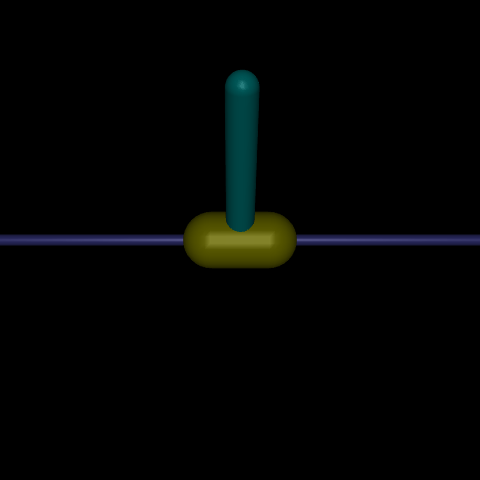

In [25]:
mean_ret, std_ret = evaluate(policy_net, n_episodes=30)
print(f"V6-continuous greedy return on {ENV_NAME}: {mean_ret:.1f} +/- {std_ret:.1f}")
print("InvertedPendulum-v5 is 'solved' at ~1000.0 (pole balanced the full episode).")
record_gif(policy_net, "v6_continuous_baseline.gif")

---
*V6-continuous ports the V6_1 pipeline to a continuous action space with the smallest possible
diff: a Gaussian head with a learned log-std, `Independent(Normal, 1)` so the update code doesn't
change, action clipping at the env boundary, and `ACT_DIM` grids. The GAE + autoreset bootstrap,
the shuffled loader, the clipped minibatch SGD, and the KL brake are all exactly as before — the
same machinery now drives a MuJoCo robot instead of a discrete swing-up. Natural next stops:
`HalfCheetah-v5` / `Hopper-v5`, where obs/reward normalization (notes §B1–B2) start to matter.*